## Imports

In [27]:
from datasets                        import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics                 import confusion_matrix
from sklearn.metrics                 import ConfusionMatrixDisplay
from sklearn.linear_model            import LogisticRegression
from sklearn.naive_bayes             import MultinomialNB
from sklearn.metrics                 import accuracy_score

import matplotlib.pyplot as plt

## Investigação inicial dos dados

In [28]:
dados = load_dataset("imdb")
print(dados)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})


Os dados do IMDb, nesse caso, não estão como um DataFrame Pandas ou um array de NumPy, e sim como um dicionário com 3 chaves:
- train: dados para treinar o modelo
- test: dados para testar o modelo
- unsupervised: dados sem rótulo, para modelos não supervisionados

Será usado nesse projeto o modelo TF-IDF para transformar e extrair as features, que serão usadas no modelo, na etapa seguinte, para classificação do texto (review positiva ou review negativa).

In [29]:
# Dados de treino

dados_treino = dados["train"]

x_treino = [x["text"]  for x in dados_treino]
y_treino = [y["label"] for y in dados_treino]

# Dados de teste

dados_teste = dados["test"]

x_teste = [x["text"]  for x in dados_teste]
y_teste = [y["label"] for y in dados_teste]

In [30]:
print(dados_treino[0])

{'text': 'I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few and far be

Label = 0 está indicando um review negativo, enquanto que o label = 1 indica um review positivo.

## Pré-processamento e Representação vetorial
Serão aplicadas duas abordagens de vetorização, Bag of Words (BoW) e TF-IDF, para alimentar os modelos na seção seguinte e comparar seus resultados.

In [31]:
vetorizadores = {
    "Bag of Words (BoW)": CountVectorizer(min_df=5),
    "TF-IDF": TfidfVectorizer(min_df=5)
}

dados_vetorizados = {}

for nome_vetorizador, vetorizador in vetorizadores.items():

    # Criar vetores a partir dos tokens
    vetor_x_treino = vetorizador.fit_transform(x_treino) # aprende o vocabulário de treino e vetoriza
    vetor_x_teste  = vetorizador.transform(x_teste) # não aprende o vocabulário de teste, só vetoriza

    dados_vetorizados[nome_vetorizador] = (vetor_x_treino, vetor_x_teste)

    vocabulario = vetorizador.get_feature_names_out()

    if nome_vetorizador == "TF-IDF": 
        print(f"Tamanho do vocabulário {nome_vetorizador}: {len(vocabulario)} palavras.")
        print("Amostras do vocabulário:")
        for i in range(10):
            j = i * 2500
            print(f"- {i+1}: {vocabulario[j]}, {vocabulario[j+1]}, {vocabulario[j+2]}, ...")

Tamanho do vocabulário TF-IDF: 27272 palavras.
Amostras do vocabulário:
- 1: 00, 000, 007, ...
- 2: bets, betsy, bettany, ...
- 3: complicit, complicity, compliment, ...
- 4: dressed, dresser, dresses, ...
- 5: gainey, gaining, gains, ...
- 6: inger, ingmar, ingram, ...
- 7: martians, martin, martindale, ...
- 8: parker, parking, parkins, ...
- 9: repairs, repartee, repay, ...
- 10: solar, solaris, sold, ...


Com isso, os vetorizadores (BoW e TF-IDF) aprendem o vocabulário a partir dos dados de treino e geram representações vetoriais dos textos (teste e treino), resultando em `vetor_x_treino` e `vetor_x_teste`.

Esses vetores podem então ser utilizados como entrada para modelos de machine learning.

**OBS:**
Optou-se por filtrar o vocabulário utilizando o parâmetro `min_df=5`, removendo palavras com frequência muito baixa. Isso ajuda a reduzir ruído e tornar a representação mais eficiente.

## Treino dos modelos
Nessa seção, serão treinados os modelos de Naive-Bayes e Regressão logística, usando tanto os dados gerados via BoW como TF-IDF.

Acurácia do modelo de Regressão Logística (Bag of Words (BoW)): 86.32 %


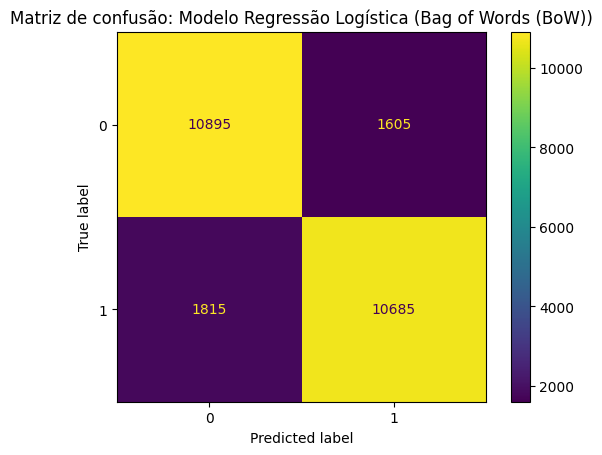

Acurácia do modelo de Naive Bayes (Bag of Words (BoW)): 81.57 %


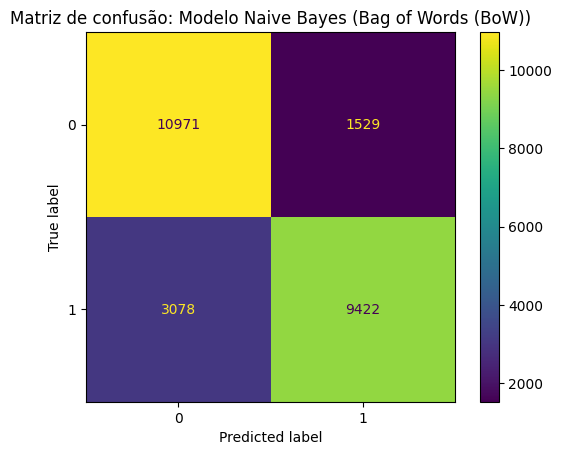

Acurácia do modelo de Regressão Logística (TF-IDF): 88.37 %


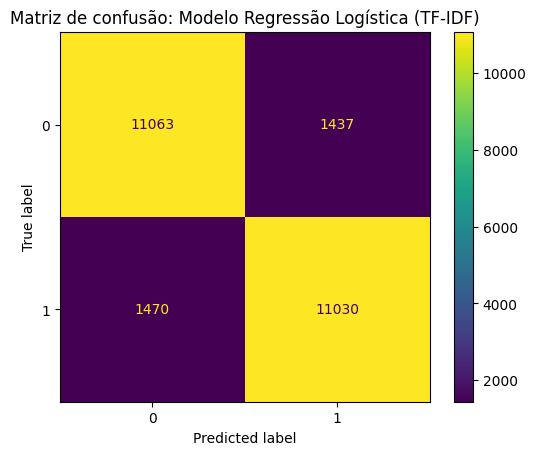

Acurácia do modelo de Naive Bayes (TF-IDF): 83.22 %


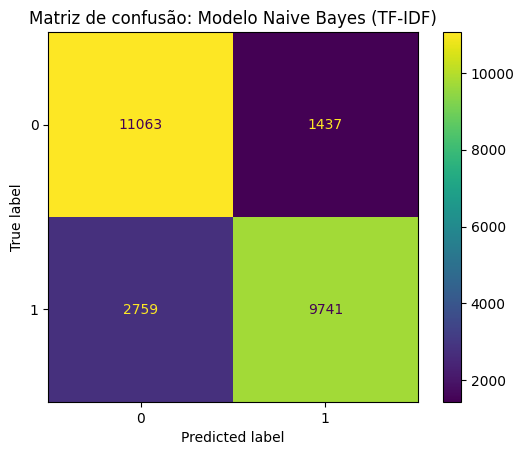

In [32]:
modelos = {
    "Regressão Logística": LogisticRegression(
        random_state=120, 
        max_iter=1000
    ),
    "Naive Bayes": MultinomialNB()
}

for nome_vetorizador, (vetor_x_treino, vetor_x_teste) in dados_vetorizados.items():

    for nome_modelo, modelo in modelos.items():

        modelo.fit(vetor_x_treino, y_treino)
        previsoes = modelo.predict(vetor_x_teste)
        
        acuracia_modelo = accuracy_score(y_teste, previsoes) * 100
        print(f"Acurácia do modelo de {nome_modelo} ({nome_vetorizador}): {acuracia_modelo:.2f} %")
        
        confusion_matrix(y_teste, previsoes)
        ConfusionMatrixDisplay.from_predictions(y_teste, previsoes)
        plt.title(f"Matriz de confusão: Modelo {nome_modelo} ({nome_vetorizador})")
        plt.show()

## Conclusão

Neste projeto, foram comparadas duas abordagens de vetorização de texto (Bag of Words e TF-IDF) combinadas com dois modelos de classificação (Naive Bayes e Regressão Logística).

Os resultados mostraram que:

- O uso de TF-IDF superou o Bag of Words em ambos os modelos, indicando que a ponderação de termos traz uma representação mais informativa dos textos.
- A Regressão Logística apresentou melhor desempenho que o Naive Bayes, possivelmente por ser um modelo mais flexível e capaz de capturar relações mais complexas entre as features.

De forma geral, a combinação de TF-IDF com Regressão Logística apresentou o melhor desempenho, alcançando aproximadamente 88% de acurácia.

Além disso, o projeto evidenciou a importância de:

- separar corretamente dados de treino e teste também na etapa de vetorização, para evitar data leakege
- reduzir ruído no vocabulário (ex: uso de `min_df`)
- entender que etapas como vetorização também envolvem um tipo de "aprendizado", ainda que não supervisionado

Como próximos passos, poderiam ser explorados modelos mais avançados de NLP.